#Weather Data Analysis

#1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set(style="whitegrid")

#2.Load Dataset

In [ ]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


#3.Dataset Overview

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (1462, 5)

Column Names:
['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB

Statistical Summary:


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


#4.Data Quality Check

In [ ]:
print("===== DATA QUALITY REPORT =====")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

===== DATA QUALITY REPORT =====

Missing Values:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicate Rows:
0


#5.Data Cleaning

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("Data Cleaning Completed")

Data Cleaning Completed


#6.Statistical Analysis

In [ ]:
print("Average Temperature:", df['meantemp'].mean())

print("Median Temperature:", df['meantemp'].median())

print("Maximum Temperature:", df['meantemp'].max())

print("Minimum Temperature:", df['meantemp'].min())

Average Temperature: 25.495520655761762
Median Temperature: 27.714285714285715
Maximum Temperature: 38.71428571428572
Minimum Temperature: 6.0


#7.Correlation Analysis

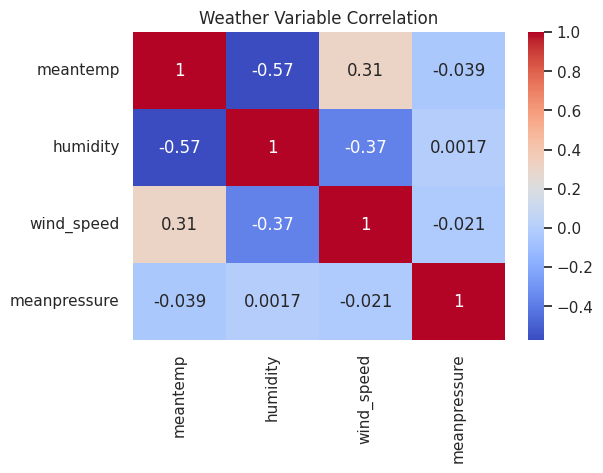

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['meantemp','humidity','wind_speed','meanpressure']].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Weather Variable Correlation")

plt.show()

#8.Visualization

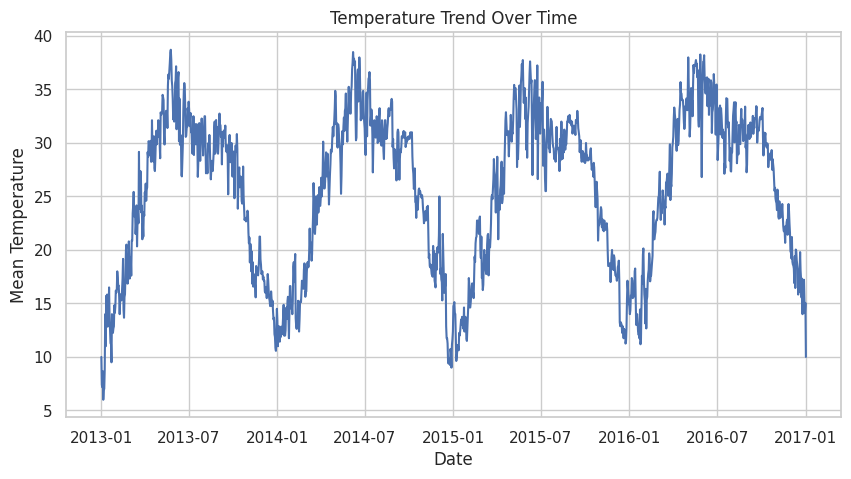

In [ ]:
#Temperature Trend Over Time

plt.figure(figsize=(10,5))

plt.plot(df['date'], df['meantemp'])

plt.title("Temperature Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Mean Temperature")

plt.show()

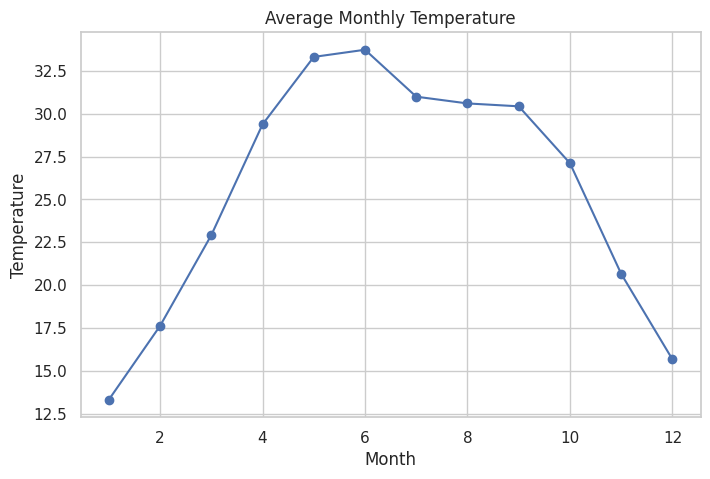

In [ ]:
#Monthly Temperature Pattern

monthly_temp = df.groupby('month')['meantemp'].mean()

plt.figure(figsize=(8,5))

monthly_temp.plot(marker='o')

plt.title("Average Monthly Temperature")

plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

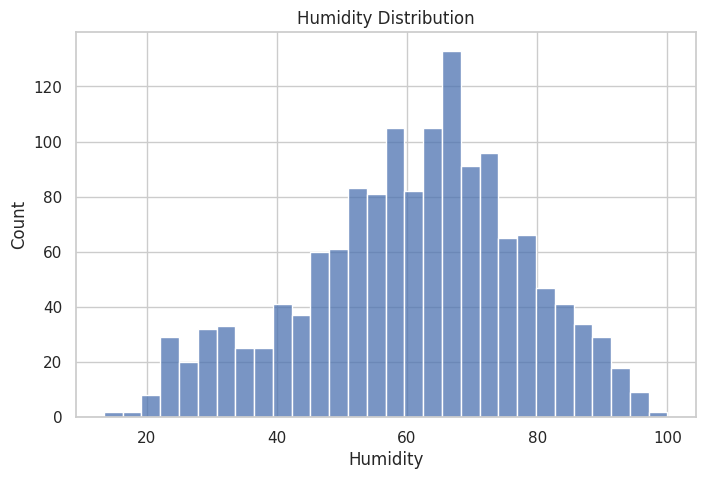

In [ ]:
#Humidity Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['humidity'], bins=30)

plt.title("Humidity Distribution")

plt.xlabel("Humidity")

plt.show()

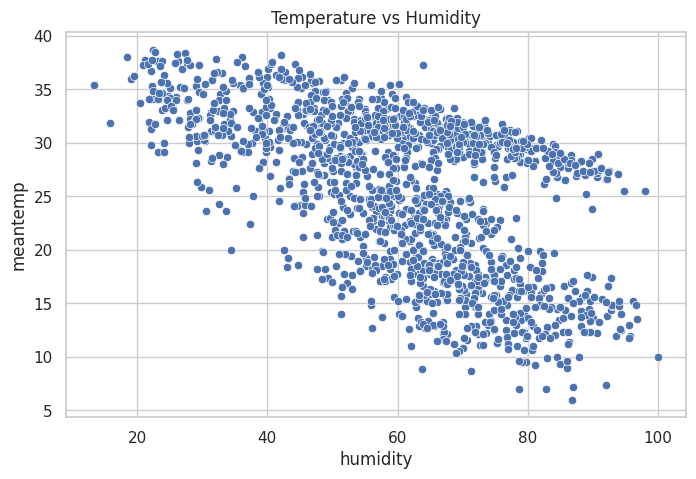

In [ ]:
#Temperature vs Humidity
plt.figure(figsize=(8,5))

sns.scatterplot(x='humidity', y='meantemp', data=df)

plt.title("Temperature vs Humidity")

plt.show()

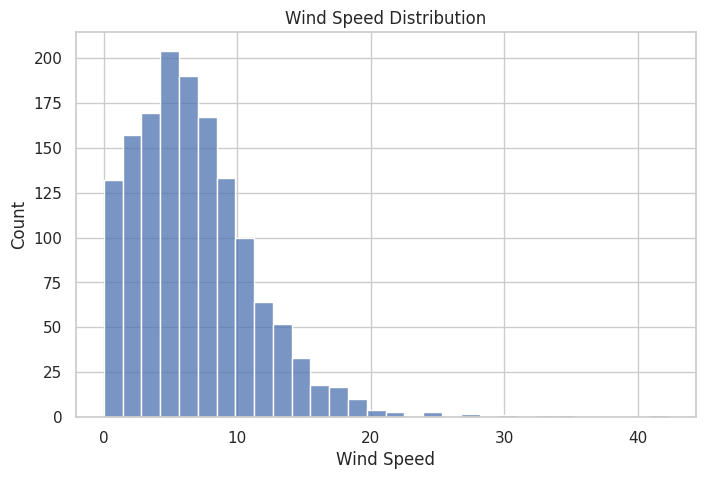

In [ ]:
#Wind Speed Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['wind_speed'], bins=30)

plt.title("Wind Speed Distribution")

plt.xlabel("Wind Speed")

plt.show()

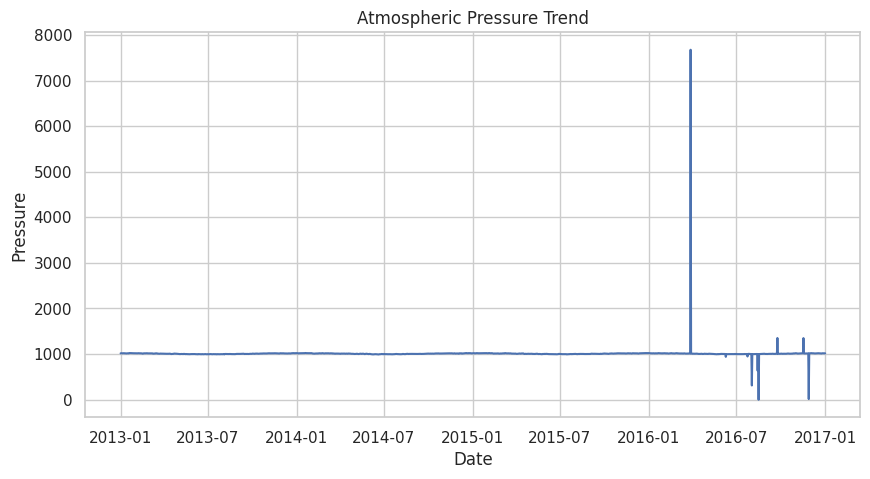

In [ ]:
#Atmospheric Pressure Trend
plt.figure(figsize=(10,5))

plt.plot(df['date'], df['meanpressure'])

plt.title("Atmospheric Pressure Trend")

plt.xlabel("Date")
plt.ylabel("Pressure")

plt.show()

#Extreme Weather Detection

In [ ]:
print("Highest Temperature Recorded:", df['meantemp'].max())

print("Lowest Temperature Recorded:", df['meantemp'].min())

print("Highest Wind Speed:", df['wind_speed'].max())

Highest Temperature Recorded: 38.71428571428572
Lowest Temperature Recorded: 6.0
Highest Wind Speed: 42.22


#Automated Weather Report

In [ ]:
print("===== WEATHER ANALYSIS REPORT =====")

print("\nAverage Temperature:", df['meantemp'].mean())

print("\nAverage Humidity:", df['humidity'].mean())

print("\nAverage Wind Speed:", df['wind_speed'].mean())

print("\nAverage Pressure:", df['meanpressure'].mean())

print("\nHottest Day Temperature:", df['meantemp'].max())

print("\nColdest Day Temperature:", df['meantemp'].min())

===== WEATHER ANALYSIS REPORT =====

Average Temperature: 25.495520655761762

Average Humidity: 60.77170158004638

Average Wind Speed: 6.802208747447473

Average Pressure: 1011.1045475940377

Hottest Day Temperature: 38.71428571428572

Coldest Day Temperature: 6.0


## Results and Observations

The weather dataset contains daily climate observations including temperature, humidity, wind speed, and atmospheric pressure. The dataset was first explored to understand its structure and to verify data quality.

Data quality checks confirmed that the dataset does not contain missing values or duplicate records. The date column was converted into a proper datetime format, allowing time-based analysis of climate patterns.

Statistical analysis revealed that the average temperature remained relatively stable throughout the dataset period with moderate fluctuations. The distribution of humidity levels indicates that humidity values vary significantly across different days.

The correlation analysis between weather variables shows moderate relationships among temperature, humidity, wind speed, and atmospheric pressure. Temperature trends plotted over time reveal seasonal variations, with certain months experiencing higher temperatures.

Wind speed distribution shows that most days experience low to moderate wind speeds, while extreme wind conditions occur less frequently. Atmospheric pressure also shows slight variations over time but generally remains within a stable range.

## Key Insights

Several important climate insights were identified from the analysis:

1. Temperature trends demonstrate seasonal patterns where certain months consistently show higher average temperatures.

2. Humidity levels fluctuate considerably, which may influence perceived temperature and weather comfort.

3. Wind speeds remain relatively low on most days, indicating stable weather conditions for the majority of the observed period.

4. Atmospheric pressure remains mostly consistent, suggesting stable climate conditions with occasional variations.

5. Correlation analysis indicates that temperature and humidity have a moderate relationship, meaning changes in humidity levels can influence temperature perception.

## Conclusion

This project analyzed daily climate data to understand temperature trends, humidity patterns, wind speed distribution, and atmospheric pressure variations. The analysis included data preprocessing, statistical evaluation, correlation analysis, and multiple visualizations to identify important weather patterns.

The results show that temperature and humidity exhibit seasonal variations, while wind speed and atmospheric pressure remain relatively stable over time. These insights highlight the importance of continuous climate monitoring and data-driven weather analysis.

Overall, the findings from this analysis can support improved weather forecasting, climate monitoring, and environmental planning.